In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import random

In [2]:
# set style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

In [3]:
# 1. Set paths
data_dir = "../data/pad_ufes_20"
images_dir = os.path.join(data_dir, "images")
metadata_path = os.path.join(data_dir, "metadata.csv")

print(f"Images folder exists: {os.path.exists(images_dir)}")
print(f"Metadata file exists: {os.path.exists(metadata_path)}")
print(f"Number of images: {len(os.listdir(images_dir))}")

Images folder exists: True
Metadata file exists: True
Number of images: 2298


In [4]:
# 2. Load Metadata

df = pd.read_csv(metadata_path)
print(f"metadata size: {df.shape}")
print("\nFirst 5 rows:")
display(df.head())

print("\nColumns: ")
print(df.columns.to_list())

print("\nExample first image ID:", df.iloc[0])

metadata size: (2298, 26)

First 5 rows:


,patient_id,lesion_id,smoke,drink,background_father,background_mother,age,pesticide,gender,skin_cancer_history,...,diameter_2,diagnostic,itch,grew,hurt,changed,bleed,elevation,img_id,biopsed
0,PAT_1516,1765,NaN,NaN,NaN,NaN,8,NaN,NaN,NaN,...,NaN,NEV,False,False,False,False,False,False,PAT_1516_1765_530.png,False
1,PAT_46,881,False,False,POMERANIA,POMERANIA,55,False,FEMALE,True,...,5.0,BCC,True,True,False,True,True,True,PAT_46_881_939.png,True
2,PAT_1545,1867,NaN,NaN,NaN,NaN,77,NaN,NaN,NaN,...,NaN,ACK,True,False,False,False,False,False,PAT_1545_1867_547.png,False
3,PAT_1989,4061,NaN,NaN,NaN,NaN,75,NaN,NaN,NaN,...,NaN,ACK,True,False,False,False,False,False,PAT_1989_4061_934.png,False
4,PAT_684,1302,False,True,POMERANIA,POMERANIA,79,False,MALE,True,...,5.0,BCC,True,True,False,False,True,True,PAT_684_1302_588.png,True



Columns: 
['patient_id', 'lesion_id', 'smoke', 'drink', 'background_father', 'background_mother', 'age', 'pesticide', 'gender', 'skin_cancer_history', 'cancer_history', 'has_piped_water', 'has_sewage_system', 'fitspatrick', 'region', 'diameter_1', 'diameter_2', 'diagnostic', 'itch', 'grew', 'hurt', 'changed', 'bleed', 'elevation', 'img_id', 'biopsed']

Example first image ID: patient_id                          PAT_1516
lesion_id                               1765
smoke                                    NaN
drink                                    NaN
background_father                        NaN
background_mother                        NaN
age                                        8
pesticide                                NaN
gender                                   NaN
skin_cancer_history                      NaN
cancer_history                           NaN
has_piped_water                          NaN
has_sewage_system                        NaN
fitspatrick                        

In [5]:
# 3. Basic info and class distribution

label_col = 'diagnostic'  # PAD-UFES-20 uses this column
print(f"\nUsing label column: {label_col}")

print("\nClass distribution (original classes):")
print(df[label_col].value_counts())


Using label column: diagnostic

Class distribution (original classes):
diagnostic
BCC    845
ACK    730
NEV    244
SEK    235
SCC    192
MEL     52
Name: count, dtype: int64


In [6]:
# Map to binary for consistency with HAM10000 Phase 1
malignant_classes = ['BCC', 'MEL', 'SCC']  # Basal Cell Carcinoma, Melanoma, Squamous Cell Carcinoma
df['binary_label'] = df[label_col].apply(lambda x: 'Malignant' if x in malignant_classes else 'Benign')

print("\nBinary class distribution:")
print(df['binary_label'].value_counts())


Binary class distribution:
binary_label
Benign       1209
Malignant    1089
Name: count, dtype: int64


C:\Users\Sharon\AppData\Local\Temp\ipykernel_23116\2791430369.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='binary_label', palette='viridis')


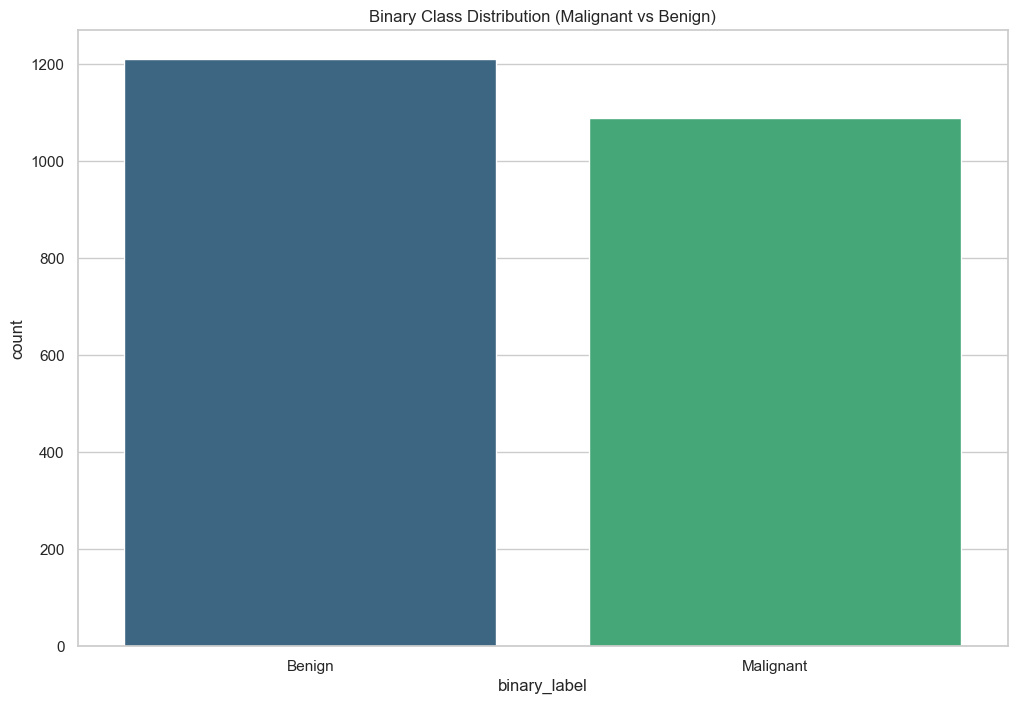

C:\Users\Sharon\AppData\Local\Temp\ipykernel_23116\2791430369.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=label_col, palette='viridis')


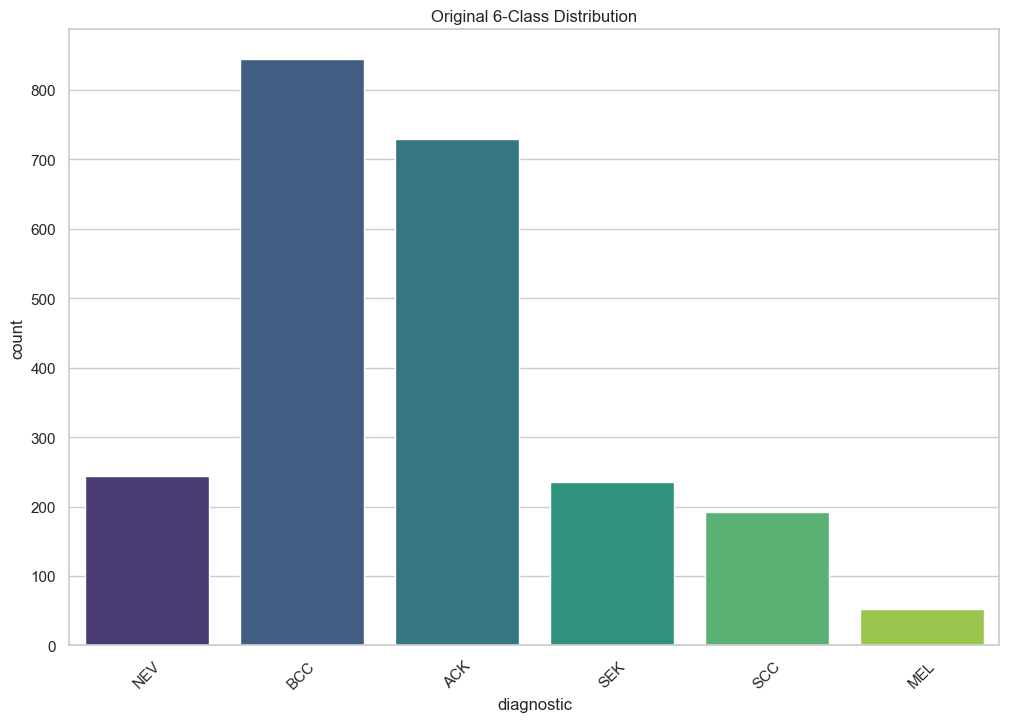

In [7]:
# Plot
plt.figure()
sns.countplot(data=df, x='binary_label', palette='viridis')
plt.title("Binary Class Distribution (Malignant vs Benign)")
plt.show()

plt.figure()
sns.countplot(data=df, x=label_col, palette='viridis')
plt.title("Original 6-Class Distribution")
plt.xticks(rotation=45)
plt.show()

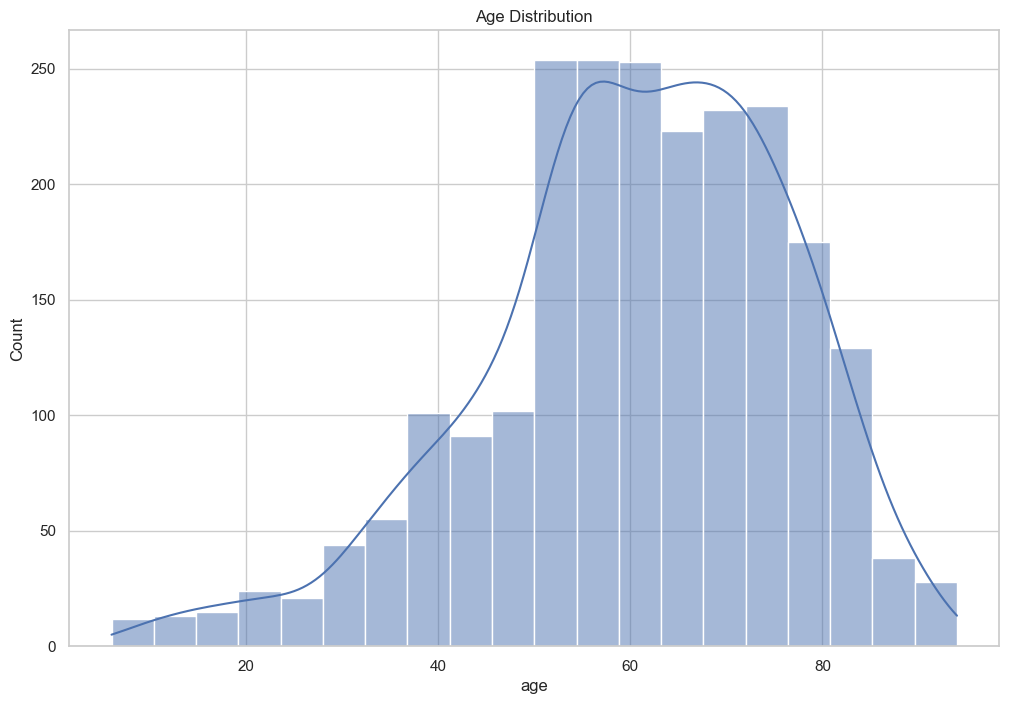

In [8]:
# 4. Metadata Analysis
# Age distribution
if 'age' in df.columns:
    plt.figure()
    sns.histplot(df['age'].dropna(), bins=20, kde=True)
    plt.title("Age Distribution")
    plt.show()

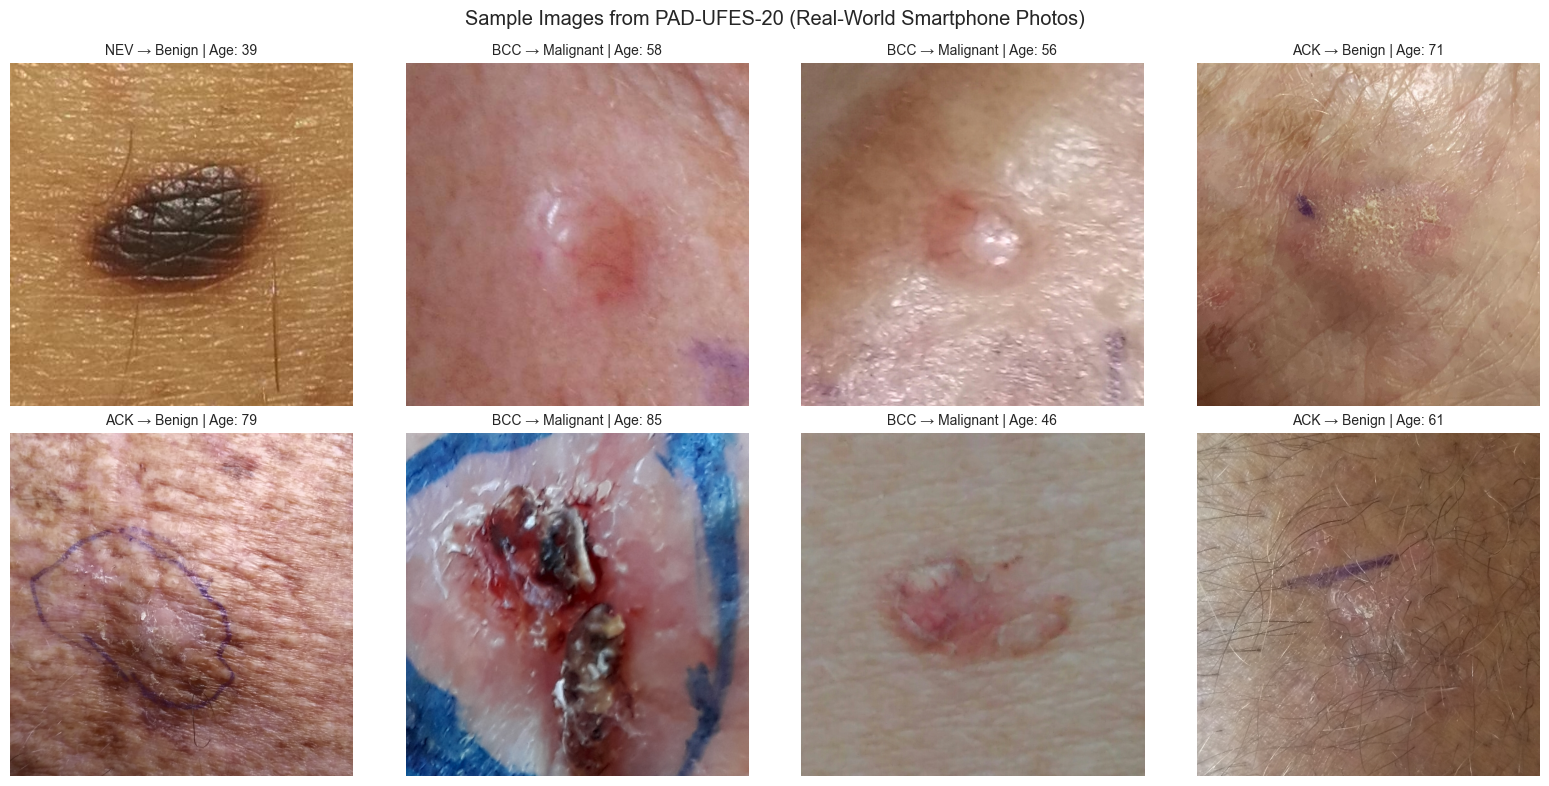

In [9]:
# 5. Sample Images Visualization 

def show_samples(df, n=8, seed=42):
    sample_df = df.sample(n=n, random_state=seed)
    
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.ravel()
    
    for idx, row in enumerate(sample_df.itertuples()):
        
        img_filename = getattr(row, 'img_id')
        
        img_path = os.path.join(images_dir, img_filename)
        
        # Safety check
        if not os.path.exists(img_path):
            print(f"Warning: Image not found → {img_path}")
            axes[idx].text(0.5, 0.5, f"Missing\n{img_filename}", ha='center', va='center', fontsize=12)
            axes[idx].axis('off')
            continue
        
        img = Image.open(img_path)
        axes[idx].imshow(img)
        
        # Title using 'diagnostic' as label_col
        title = f"{getattr(row, label_col)} → {row.binary_label}"
        if 'age' in df.columns and not pd.isna(getattr(row, 'age')):
            title += f" | Age: {int(getattr(row, 'age'))}"
        
        axes[idx].set_title(title, fontsize=10)
        axes[idx].axis('off')
    
    plt.suptitle("Sample Images from PAD-UFES-20 (Real-World Smartphone Photos)")
    plt.tight_layout()
    plt.show()

label_col = 'diagnostic'  
show_samples(df, n=8)